In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [8]:
class UserState(TypedDict):
    age: int
    output: str

In [9]:
def age(state: UserState):
    return {'age': state['age']}

def adult(state: UserState):
    result = f"{state['age']} is an adult."
    return {'output': result}

def minor(state: UserState):
    result = f"{state['age']} is a minor."
    return {'output': result}

def check_age(state: UserState) -> Literal['adult', 'minor']:
    if state['age'] >= 18:
        return 'adult'
    else:
        return 'minor'

In [10]:
graph = StateGraph(UserState)

graph.add_node("age", age)
graph.add_node("adult", adult)
graph.add_node("minor", minor)

graph.add_edge(START, "age")
graph.add_conditional_edges("age", check_age)
graph.add_edge("adult", END)
graph.add_edge("minor", END)

workflow = graph.compile()

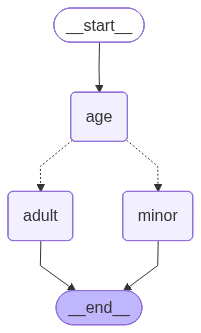

In [11]:
workflow

In [12]:
initial_state = {
    'age': 20
}
workflow.invoke(initial_state)

{'age': 20, 'output': '20 is an adult.'}